<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/drafts/Notebook9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

In [2]:
!pip install -q folium geopandas

# Data and the State (DATA 20195/30195)
# Lab 9: Neighborhoods and Communities of Interest

Based on ["An Extremely Detailed Map of New York City Neighborhoods"](https://www.nytimes.com/interactive/2023/upshot/extremely-detailed-nyc-neighborhood-map.html) (Buchanan et al. 2023)

In [3]:
import json
from math import log

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from collections import Counter
from shapely import MultiPolygon

In [4]:
# @markdown This code cell contains a helper function for our backup data in case of API failure.
import requests
import io
def read_parquet_from_github(url):
    # If there is no geometry data, then you need to read in with pandas or the
    # request will fail because geopandas expects to see a geometry column.
    r = requests.get(url)
    try:
        df = gpd.read_parquet(io.BytesIO(r.content))
    except ValueError:
        df = pd.read_parquet(io.BytesIO(r.content))
    return df

In [5]:
submissions_gdf = gpd.read_file("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_nyt_neighborhood_submissions.geojson")

In [6]:
submissions_gdf

,submission_id,neighborhood,geometry
0,s37680,Rego Park,"POLYGON ((-74.266 40.77571, -74.26758 40.7758,..."
1,s8242,Carroll Gardens,"POLYGON ((-74.18548 40.71266, -74.1855 40.7126..."
2,s19091,Mariners Harbor,"POLYGON ((-74.14712 40.62561, -74.17969 40.632..."
3,s12920,Graniteville,"POLYGON ((-74.15735 40.61335, -74.15739 40.613..."
4,s25108,Rossville,"POLYGON ((-74.2175 40.54655, -74.21751 40.5465..."
...,...,...,...
26577,s2538,Bellerose,"POLYGON ((-73.70212 40.72902, -73.71837 40.726..."
26578,s2521,Bellerose,"POLYGON ((-73.71749 40.74395, -73.71748 40.743..."
26579,s11276,Floral Park,"POLYGON ((-73.71038 40.71526, -73.71954 40.715..."
26580,s2533,Bellerose,"POLYGON ((-73.71354 40.73622, -73.71353 40.736..."


<Axes: >

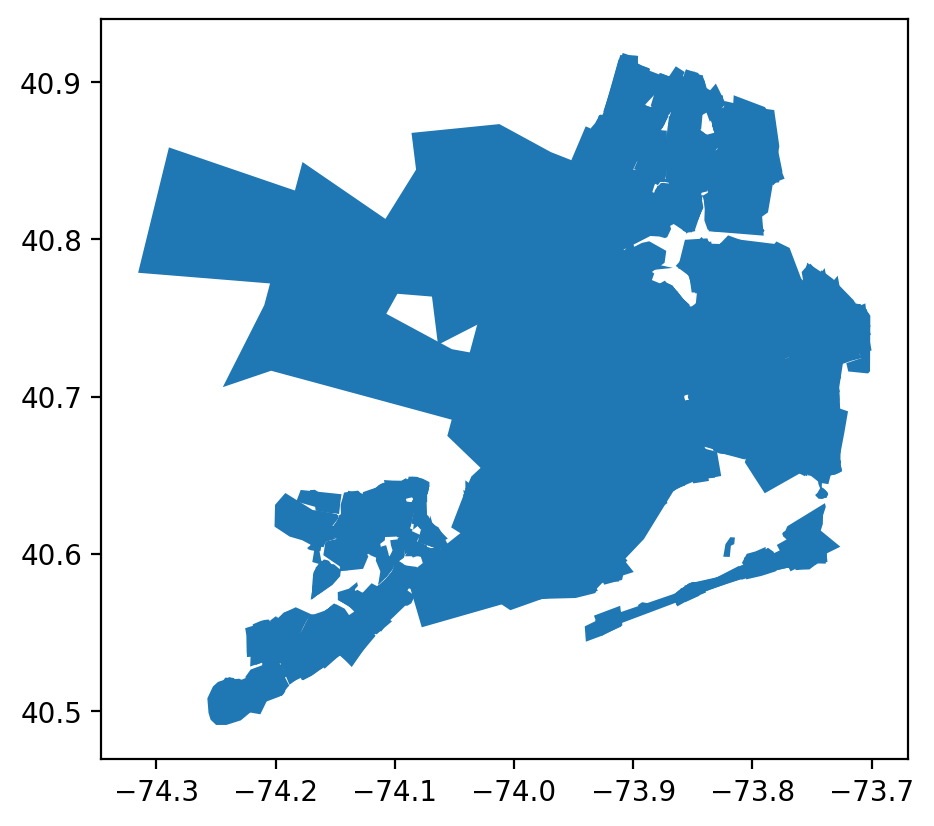

In [7]:
submissions_gdf.plot()

Each submission seems to have one neighborhood label.  These were chosen by the users together with their polygons.  There are 379 neighborhood labels.

In [8]:
submissions_gdf["neighborhood"].value_counts()

,count
neighborhood,
Upper West Side,2095
Park Slope,1033
Upper East Side,1009
East Village,847
West Village,669
...,...
Madison,1
Ravenswood,1
Mount Eden,1


It's not immediately obvious if users got to choose the neighborhood name as free text, or if they got a menu of options.  Let's see all the things called some kind of "village."

In [9]:
submissions_gdf[submissions_gdf["neighborhood"].str.contains("illage")].value_counts("neighborhood")

,count
neighborhood,
East Village,847
West Village,669
Greenwich Village,495
Peter Cooper Village,33
Middle Village,27
The Village,19
Van Cortlandt Village,15
Queens Village,15
Far West Village,11


The relative simplicity of this list strongly suggests that the NYT data folks presented people with this list of options rather than letting them enter their own free text.  Otherwise we'd expect lots of crazy misspellings and what-not!

Let's take a look at all the ones tagged as "Upper West Side"....

In [10]:
submissions_map = folium.Map(
    [40.717, -73.9754],
    zoom_start=12,
    tiles="Cartodb Positron",  # use a less cluttered basemap
)
for _, row in submissions_gdf[submissions_gdf["neighborhood"] == "Upper West Side"].iterrows():
    folium.PolyLine([(y, x) for x, y in row.geometry.exterior.coords], weight=2, opacity=0.5).add_to(submissions_map)

In [11]:
submissions_map

Amusingly, a few people don't know their East from West.... and one person is on the wrong land mass altogether.  These are the pleasures of user-submitted data!

The NYT folks did some processing, and in particular they worked out how often each census block got each tag.

In [12]:
!curl -O https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_nyt_neighborhood_block_weights.json

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3022k  100 3022k    0     0  5117k      0 --:--:-- --:--:-- --:--:-- 5122k


In [13]:
with open("Notebook9_nyt_neighborhood_block_weights.json", 'r') as f:
    block_weights = json.load(f)

In [14]:
list(block_weights.items())[:10]  # Census block GEOID -> neighborhood weights

[('360850323001008', {'Mariners Harbor': 0.514, 'Graniteville': 0.486}),
 ('360850323001007', {'Mariners Harbor': 0.515, 'Graniteville': 0.485}),
 ('360850323001005',
  {'Mariners Harbor': 0.393, 'Graniteville': 0.312, 'Elm Park': 0.295}),
 ('360850323001006',
  {'Mariners Harbor': 0.361, 'Graniteville': 0.349, 'Elm Park': 0.29}),
 ('360850323001011',
  {'Mariners Harbor': 0.35, 'Graniteville': 0.362, 'Elm Park': 0.288}),
 ('360850323001004', {'Mariners Harbor': 0.589, 'Elm Park': 0.411}),
 ('360850323001012',
  {'Mariners Harbor': 0.35, 'Graniteville': 0.362, 'Elm Park': 0.288}),
 ('360850291021034', {'Bulls Head': 0.83, 'Graniteville': 0.17}),
 ('360850323001020',
  {'Mariners Harbor': 0.319, 'Graniteville': 0.362, 'Elm Park': 0.319}),
 ('360850291022019', {'Travis': 1})]

## Neighborhood cores

In [15]:
block_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/TABBLOCK20/tl_2024_36_tabblock20.zip").set_index("GEOID20")

There are (at least) two ways of thinking about the level of disagreement.

Definition 1: of the submissions that include `block X`, what share labeled it as `neighborhood Y`? (in other words: what do New Yorkers call this block?)

Definition 2: of the submissions that are labeled with `neighborhood Y`, what share include `block X`? (in other words: among the people with an opinion on where that neighborhood is, do they include this block?)



So now we'll define a `core` function, which lets you choose a neighborhood and then picks all the blocks where at least `cutoff` share of submitters gave it that label.  (You can choose the cutoff!)

Note: This is based on the kind of consensus that's measured in Definition 1 above.

In [16]:
def core(neighborhood, gdf, weights_dict, cutoff=0):  # def. (1)
    neighborhood_weights = {
        geoid: weights[neighborhood]
        for geoid, weights in weights_dict.items()
        if neighborhood in weights and weights[neighborhood] >= cutoff
    }
    core_gdf = gdf.loc[neighborhood_weights.keys()]
    core_gdf["weight"] = neighborhood_weights
    return core_gdf.reset_index()

In [17]:
core_gdf = core("Upper West Side", block_gdf, block_weights, cutoff=0.1)

core_gdf.head()

,GEOID20,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry,weight
0,360610163001005,36,061,016300,1005,1000000US360610163001005,Block1005,G5040,U,63217,S,5402,0,+40.7829353,-073.9834453,151,225,"POLYGON ((-73.98433 40.78332, -73.98408 40.783...",0.999
1,360610163001003,36,061,016300,1003,1000000US360610163001003,Block1003,G5040,U,63217,S,13289,0,+40.7837001,-073.9827506,483,904,"POLYGON ((-73.9833 40.78435, -73.98166 40.7836...",1.000
2,360610167002001,36,061,016700,2001,1000000US360610167002001,Block2001,G5040,U,63217,S,13134,0,+40.7843298,-073.9821952,416,778,"POLYGON ((-73.98264 40.78498, -73.98116 40.784...",1.000
3,360610163001004,36,061,016300,1004,1000000US360610163001004,Block1004,G5040,U,63217,S,8650,0,+40.7831912,-073.9831548,239,372,"POLYGON ((-73.98425 40.78341, -73.9839 40.7837...",0.999
4,360610163002001,36,061,016300,2001,1000000US360610163002001,Block2001,G5040,U,63217,S,12723,0,+40.7817928,-073.9841010,499,591,"POLYGON ((-73.98478 40.78248, -73.98305 40.781...",0.990


Let's visualize (as a heatmap) Definition 1 of "Upper West Side."

In [18]:
core_map = folium.Map(
    [40.787, -73.9754],
    zoom_start=13,
    tiles="Cartodb Positron",  # use a less cluttered basemap
)

folium.Choropleth(
    geo_data=core_gdf,
    data=core_gdf,
    columns=["GEOID20", "weight"],
    key_on="feature.properties.GEOID20",
    fill_color="OrRd",
).add_to(core_map)

core_map

### TASK: Two Versions of the Upper West Side

The function `core` above implemented definition 1 of the neighborhood core. In the code cells below, implement definition 2:

> Of the submissions that are labeled with neighborhood Y, what share include block X? (in other words: among the people with an opinion on where that neighborhood is, do they include this block?)

and create a matplotlib choropleth comparing the two definitions.

How do the two definitions compare?

In [19]:
def core_v2(neighborhood, census_blocks_gdf, submissions_gdf, cutoff=0):
    ## 1. Filter the submisssions to only this neighborhood

    # nbhd_subs =             # <- YOUR CODE HERE
    # total = len(nbhd_subs)

    ## 2. Put GEOID20 in a normal column (it starts out as the index) so we can group on it later.
    if "GEOID20" not in census_blocks_gdf.columns:
        census_blocks_gdf = census_blocks_gdf.reset_index()
    blocks = census_blocks_gdf.to_crs("EPSG:4326")

    ## 3. Spacially join the blocks gdf with the nbhd_subs gdf to create a new
    ## gdf with one row for each (block, submission) overlap

    # joined =  # <- YOUR CODE HERE

    ## 4. Count how many submissions intersect each block, then divide by total
    ## (Just comment back in the lines below)

    # counts = joined.groupby("GEOID20").size()
    # weights_df = counts.reset_index(name="count")
    # weights_df["weight"] = weights_df["count"] / total

    ## 5. Filter the weights_df to those above the cutoff

    # weights_df =  # <- YOUR CODE HERE

    ## 6. Merge the weights back onto the block shapes (matching on GEOID20)

    out = blocks # FIX ME!!!

    return out

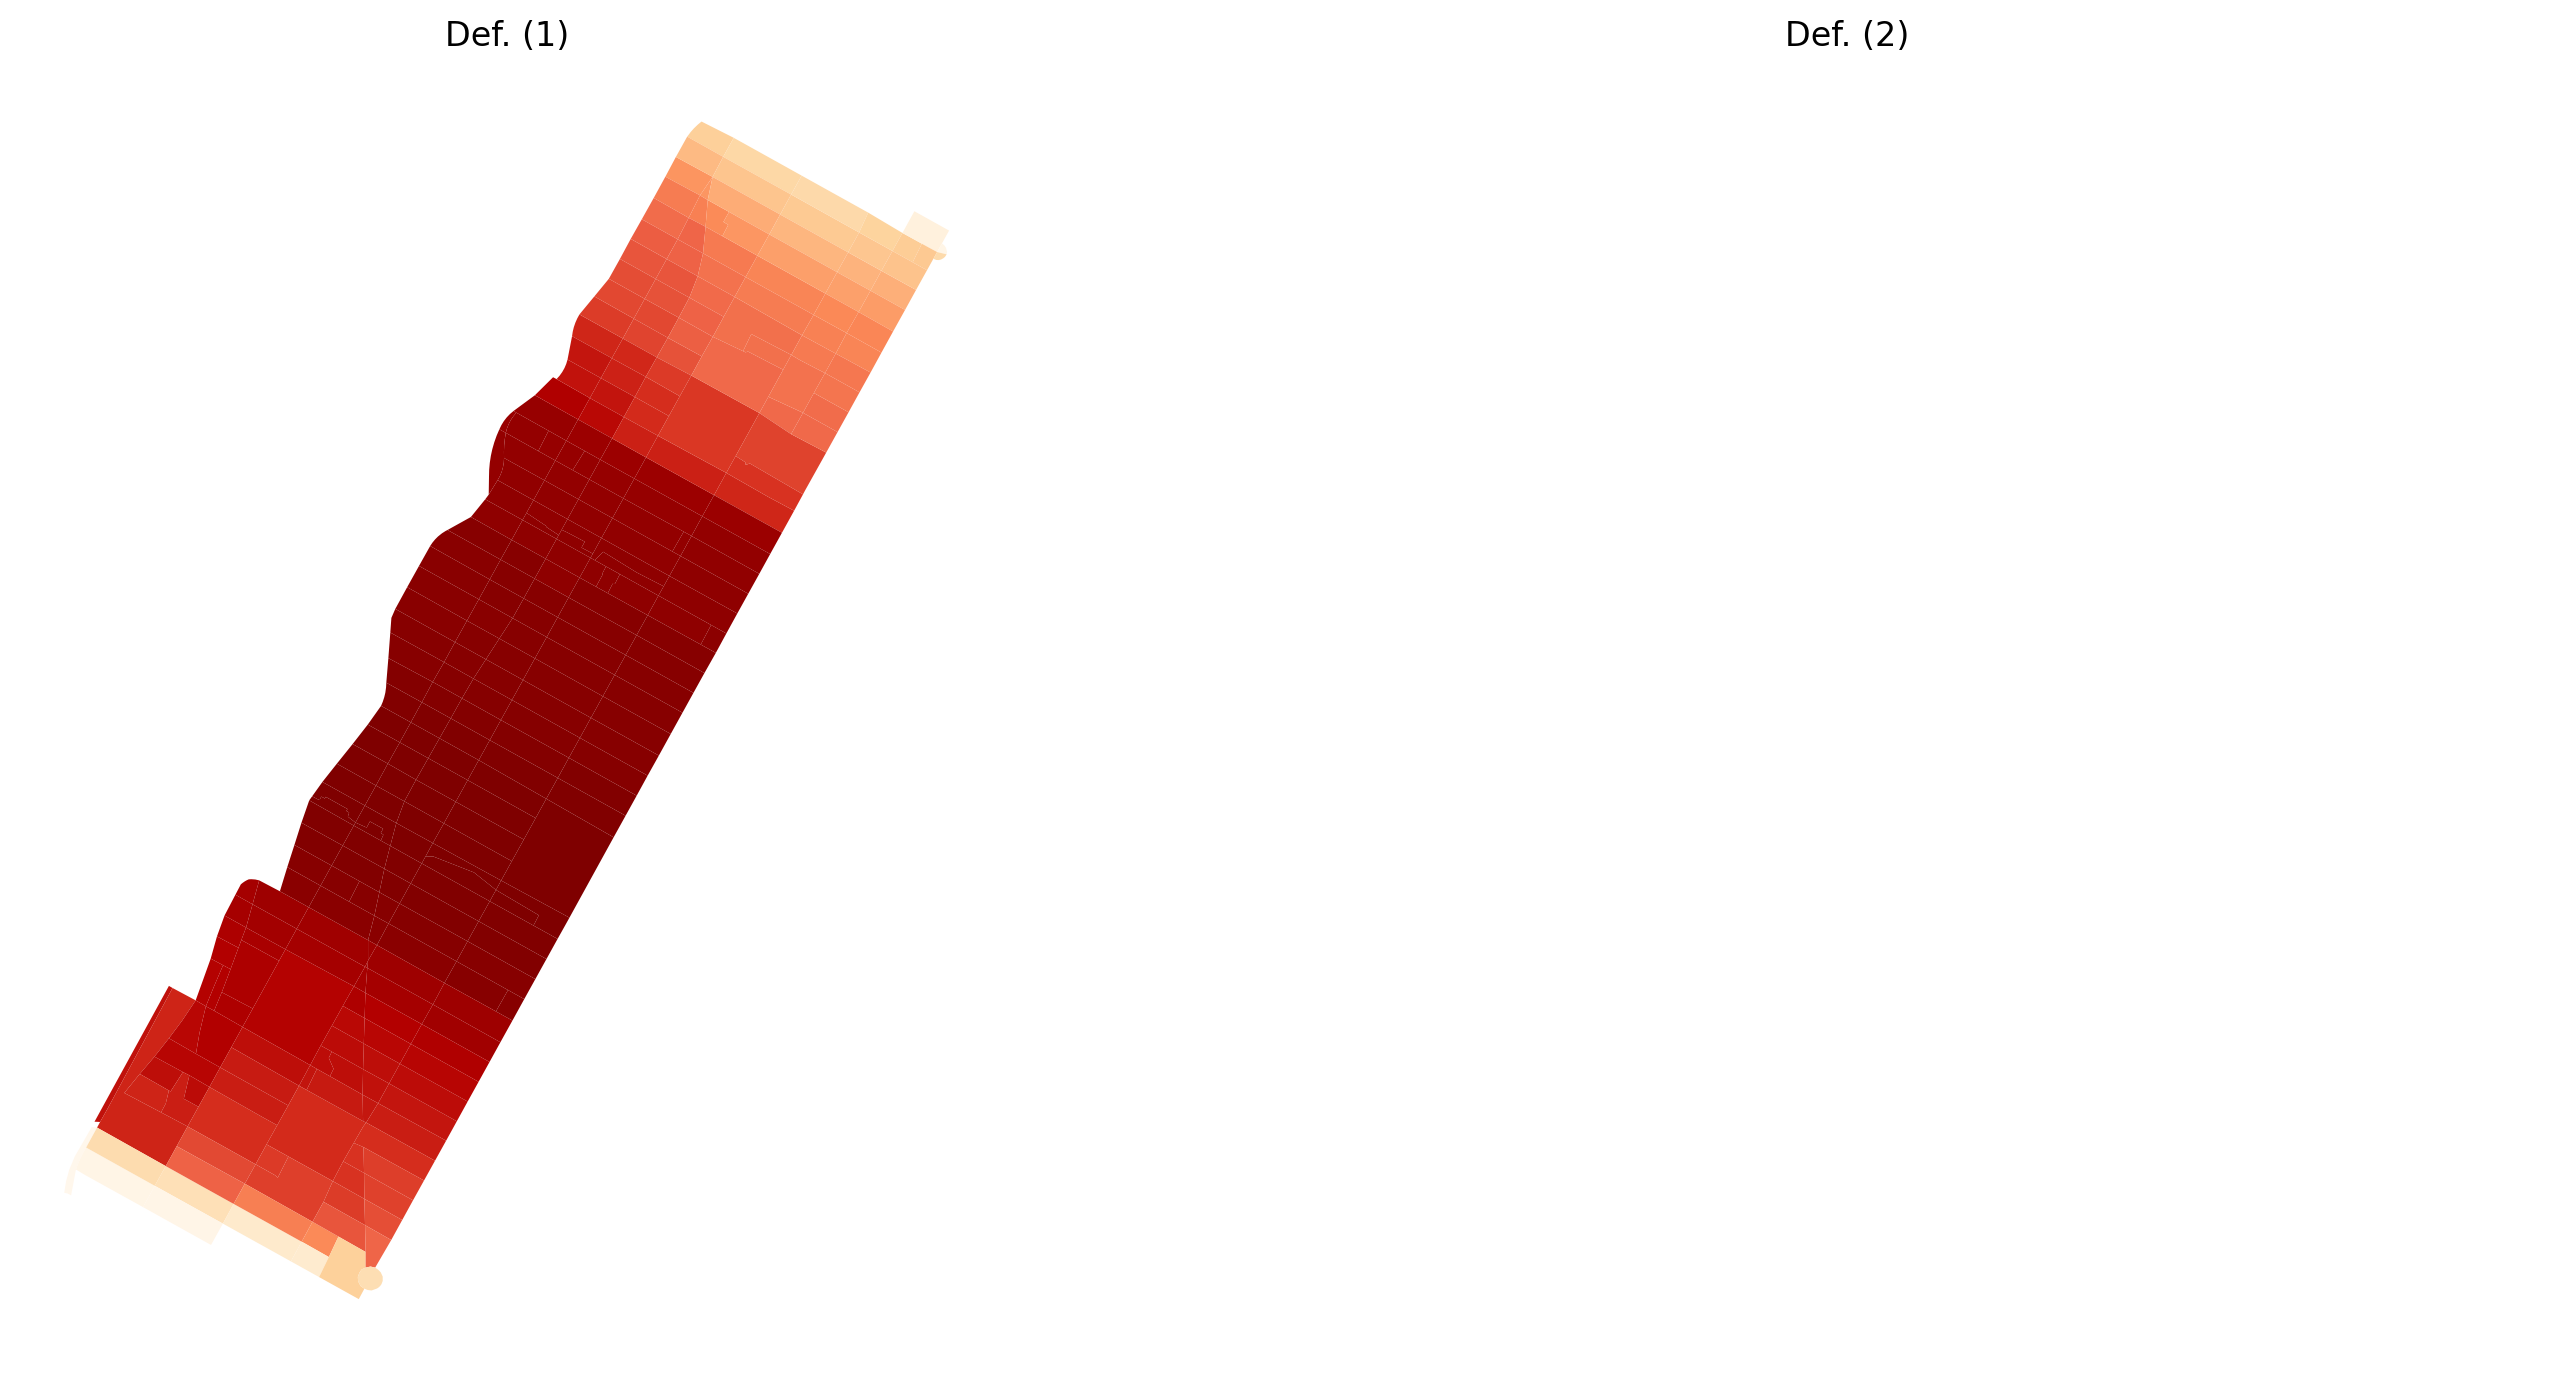

In [20]:
# There are some things that you can do to improve the quality of these plots!

core_gdf = core("Upper West Side", block_gdf, block_weights, cutoff=0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

core_gdf.plot(
    column="weight",
    cmap="OrRd",
    ax=axes[0]
)
axes[0].set_title("Def. (1)")
axes[0].set_axis_off()

# core2_gdf = core_v2("Upper West Side", block_gdf, submissions_gdf, cutoff=0.1)

# core2_gdf.plot(
#     column="weight",
#     cmap="OrRd",
#     ax=axes[1]
# )
axes[1].set_title("Def. (2)")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [21]:
block_neighborhood_counts = {
    geoid: len(weights)
    for geoid, weights in block_weights.items()
}

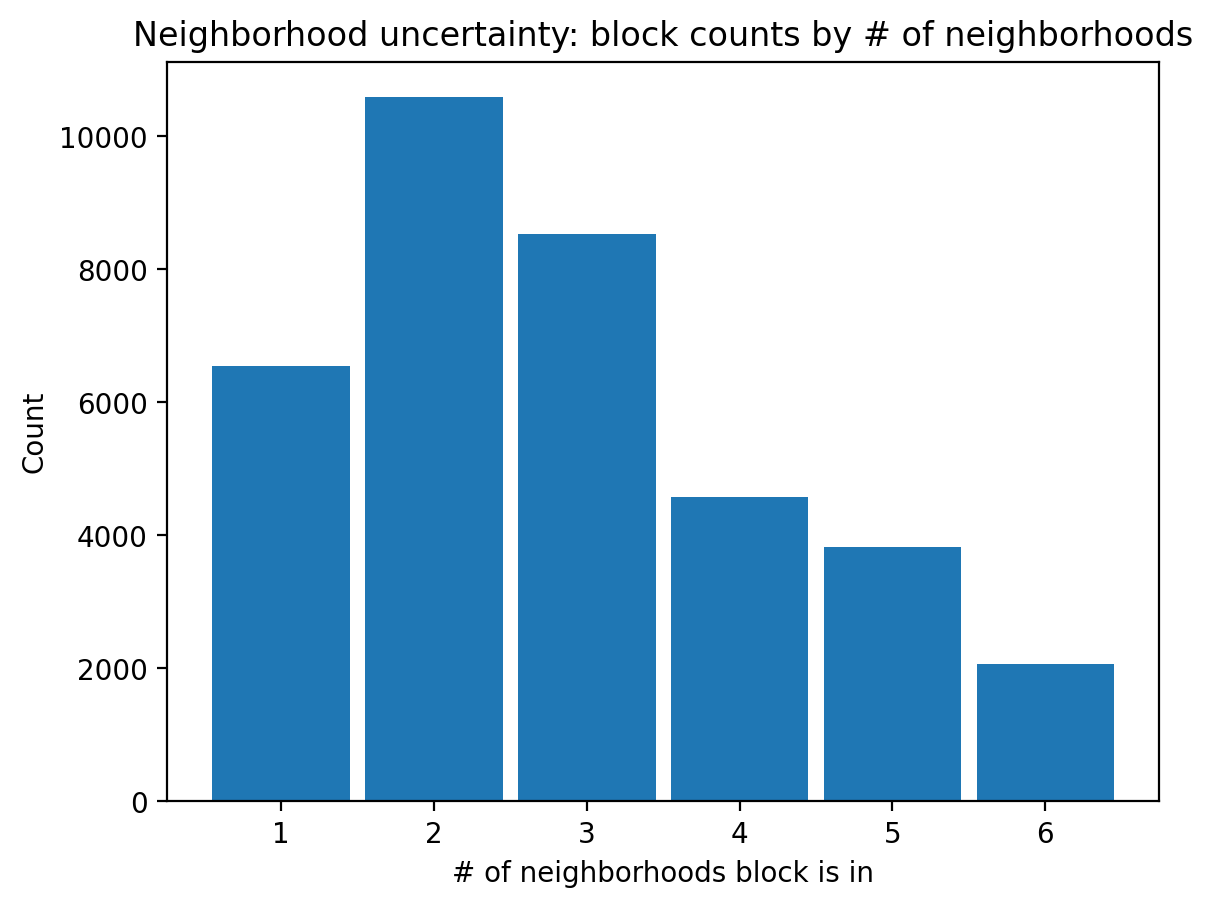

In [22]:
plt.hist(block_neighborhood_counts.values(), bins=np.arange(1, 8)-0.5,rwidth=0.9)
plt.title("Neighborhood uncertainty: block counts by # of neighborhoods")
plt.xlabel("# of neighborhoods block is in")
plt.ylabel("Count")
plt.show()

For each block, we'll sum over its weight vector to get a measure of uncertainty about its neighborhood assignment.  We'll use the math concept called *Shannon entropy*, which was explained in class:  it is made by $H=\sum w_i \log w_i$ over the coordinates $i$.  So if a block is called "West Village" 100 times but "The Village" just once, its Shannon entropy is low, which means there's not significant disagreement.  But if it gets each label 50 times, it gets a higher score $H=1$.  And if it gets THREE labels each an equal number of times, it gets an even higher score $H=1.585$.  Basically you should think of $H$ as measuring the level of split-up-ness or controversy about the label.

In [23]:
block_entropies = {
    geoid: -sum(v * log(v) for v in weights.values())
    for geoid, weights in block_weights.items()
}

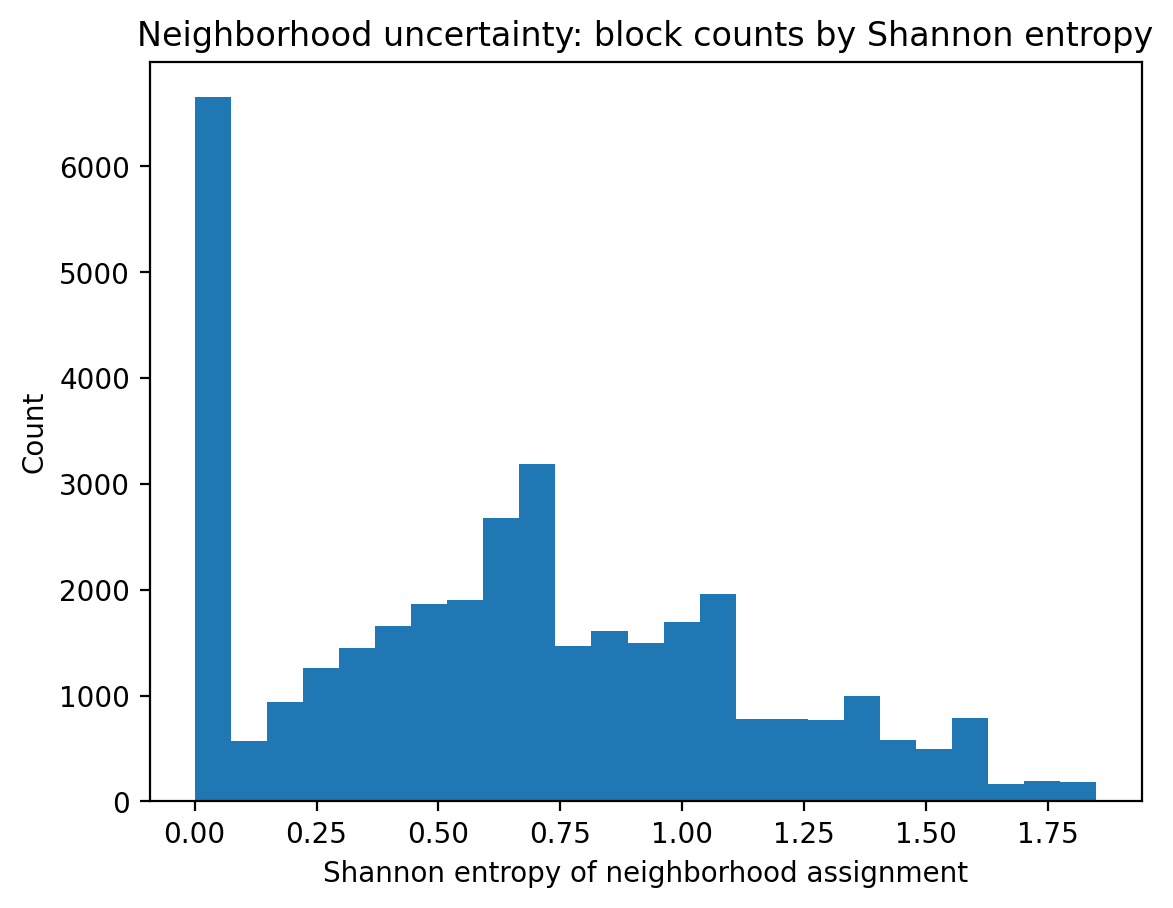

In [24]:
plt.hist(block_entropies.values(), bins=25)
plt.title("Neighborhood uncertainty: block counts by Shannon entropy")
plt.xlabel("Shannon entropy of neighborhood assignment")
plt.ylabel("Count")
plt.show()

In [25]:
block_gdf["entropy"] = block_entropies
nyc_gdf = block_gdf.loc[block_entropies.keys()].reset_index()

In [26]:
nyc_gdf.head(5)

,GEOID20,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry,entropy
0,360850323001008,36,085,032300,1008,1000000US360850323001008,Block1008,G5040,U,63217,S,33899,0,+40.6347918,-074.1940734,0,0,"POLYGON ((-74.19589 40.63525, -74.19527 40.636...",0.692755
1,360850323001007,36,085,032300,1007,1000000US360850323001007,Block1007,G5040,U,63217,S,0,15774,+40.6351631,-074.1934565,0,0,"POLYGON ((-74.19511 40.63644, -74.19496 40.636...",0.692697
2,360850323001005,36,085,032300,1005,1000000US360850323001005,Block1005,G5040,U,63217,S,352270,0,+40.6376836,-074.1891917,0,0,"POLYGON ((-74.19313 40.63919, -74.19037 40.640...",1.090573
3,360850323001006,36,085,032300,1006,1000000US360850323001006,Block1006,G5040,U,63217,S,93574,0,+40.6360535,-074.1919253,0,0,"POLYGON ((-74.19476 40.63705, -74.19461 40.637...",1.094185
4,360850323001011,36,085,032300,1011,1000000US360850323001011,Block1011,G5040,U,63217,S,213124,0,+40.6330968,-074.1884338,0,0,"POLYGON ((-74.19265 40.63476, -74.19253 40.635...",1.093771


In [27]:
top_neighborhoods = submissions_gdf["neighborhood"].value_counts().head(100)
top_neighborhoods

,count
neighborhood,
Upper West Side,2095
Park Slope,1033
Upper East Side,1009
East Village,847
West Village,669
...,...
Bensonhurst,41
Kew Gardens,40
East Elmhurst,40


In [28]:
neighborhood_blocks = {neighborhood: [] for neighborhood in top_neighborhoods.keys()}
for geoid, weights in block_weights.items():
    for neighborhood, weight in weights.items():
        if neighborhood in neighborhood_blocks and weight > 0.3:  # increase this cutoff to tighten boundaries
            neighborhood_blocks[neighborhood].append(geoid)

In [29]:
neighborhood_geos = {
    name: block_gdf.loc[geoids].dissolve().geometry
    for name, geoids in neighborhood_blocks.items()
}

And so we'll finish this notebook with a Folium map that plots the "core" neighborhoods (for the threshold you chose above).  And this should also have a checkbox in the upper right that lets you turn on and off a heatmap of the entropy score so you can see where there's the most label controversy!

In [30]:
entropy_map = folium.Map(
    [40.65, -73.95],
    zoom_start=12,
    tiles="Cartodb Positron",
)
colors = ['#0099cd', '#ffca5d', '#00cd99', '#99cd00', '#cd0099', '#aa44ef', '#8dd3c7', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#bc80bd', '#ccebc5', '#ffed6f', '#ffffb3', '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#b15928', '#64ffda', '#00B8D4', '#A1887F', '#76FF03', '#DCE775', '#B388FF', '#FF80AB', '#D81B60', '#26A69A', '#FFEA00', '#6200EA']

folium.Choropleth(
    geo_data=nyc_gdf,
    data=nyc_gdf,
    columns=["GEOID20", "entropy"],
    key_on="feature.properties.GEOID20",
    name="Neighborhood uncertainty (Shannon entropy)",
    fill_color="OrRd",
    line_opacity=0.2,
    fill_opacity=0.5,
    show=False,
).add_to(entropy_map)

for idx, (neighborhood, geos) in enumerate(neighborhood_geos.items()):
    if len(geos) > 0:
        for geo in geos:
            if isinstance(geo, MultiPolygon):
                for part in geo.geoms:
                    folium.Polygon(
                        [(y, x) for x, y in part.exterior.coords],
                        weight=6,
                        tooltip=neighborhood,
                        color=colors[idx % len(colors)],
                    ).add_to(entropy_map)
            else:
                folium.Polygon(
                    [(y, x) for x, y in geo.exterior.coords],
                    weight=6,
                    tooltip=neighborhood,
                    color=colors[idx % len(colors)],
                ).add_to(entropy_map)

folium.LayerControl(collapsed=False).add_to(entropy_map)

In [ ]:
entropy_map

## Communities of Interest and Participatory Mapping

We're now going to take a look at some crowdsourced data on **communities of interest**, gathered for redistricting purposes.  This data was collected by the Data and Democracy Lab in multiple states.  You can read a blog-style post about the project [here](https://mggg.org/cois).

Below, we'll explore the data collected in two states:  Michigan and Wisconsin.

In [32]:
mi_df = read_parquet_from_github("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_mi_coi_df.parquet")
wi_df = read_parquet_from_github("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_wi_coi_df.parquet")

Let's take a look at the Michigan dataframe.  Each community map has an ID, a title, and some narrative text.  If the community contains several areas, then each area is listed -- for instance, 17892-1 and 17892-2 are two parts of the same submission that is coded 17892.  There's also a list of which census blocks make up the area.

Finally, we had a team of humans (mainly me and a bunch of students!) apply labels by hand to each submission -- that's what's in the last column.  



In [33]:
mi_df

,districtr_id,submission_title,submission_text,area_name,area_text,blocks_2020,labels
0,17124-1,Dearborn Cultural District,Cultural venues in Dearborn. Important that th...,Community 1,None,"[261635799004005, 261639838003006, 26163983800...",[]
1,17128-1,Dearborn neighborhoods near Ford Field,"Area includes residents west of Brady, north o...",Dearborn Ford Field Neighbors,"Neighborhoods using Ford Field, north of Michi...","[261635749001029, 261635749001005, 26163579900...",[]
2,17892-1,Example: Grand Rapids center and exurbs,This map shows the Grand Rapids urban center a...,urban center,The denser and more urbanized part of Grand Ra...,"[260810016002007, 260810009002022, 26081013300...",[cities]
3,17892-2,Example: Grand Rapids center and exurbs,This map shows the Grand Rapids urban center a...,exurbs,"Extending past Hudsonville to the West, these ...","[260810133002001, 260810112003002, 26081011200...",[cities]
4,17892-1,ADA reviews,0,urban center,The denser and more urbanized part of Grand Ra...,"[260810016002007, 260810009002022, 26081013300...",[cities]
...,...,...,...,...,...,...,...
1032,41407-1,"Calhoun, Branch, Hillsdale map",Grouping of like community interests,District 1,None,"[260250015003035, 260239511003057, 26025002900...",[]
1033,41415-1,Congressional district map,Groups counties with like opinions and geograp...,District 1,None,"[260910606001000, 260250031002016, 26027001000...",[]
1034,41504-1,Lakeshore District - 79th,We need to ensure lakeshore communities are re...,District 1,None,"[261590114004032, 260210102011015, 26021000900...",[]
1035,41636-1,Keith B's Congressional Plan,These counties are more rural and agricultural...,District 1,None,"[260910606001000, 260250031002016, 26059051000...","[agriculture, nimby, suburbs]"


In [34]:
wi_df

,districtr_id,submission_title,submission_text,area_name,area_text,blocks_2020,labels
0,11542-1,Community of Interest (imported),How do the political lines in Wisconsin impact...,Lake Country,None,"[551332041003050, 551332042013001, 55133204400...",[named neighborhood]
1,11542-2,Community of Interest (imported),How do the political lines in Wisconsin impact...,Dousman/Summit,Rock River watershed,"[550551016001009, 551332041001033, 55133204004...","[environment, theory]"
2,11542-4,Community of Interest (imported),How do the political lines in Wisconsin impact...,Watertown south,None,"[550551011002026, 550551003012021, 55055101100...",[environment]
3,11623-1,Community of Interest (imported),Submitting on behalf of someone else?\nNo Rece...,Community 1,North Shore - my community of interest\nShorew...,"[550790703003009, 550790602004016, 55079080100...",[community engagement]
4,11623-2,Community of Interest (imported),Submitting on behalf of someone else?\nNo Rece...,Community 2,Brown Deer - sometimes included in the North S...,"[550790501031004, 550790501013027, 55079050104...",[personal-unusable-incoherent]
...,...,...,...,...,...,...,...
1145,33670-1,University of Wisconsin- Waukesha,This community of interest was drawn to ensur...,University of Wisconsin- Waukesha,The University of Wisconsin- Waukesha is the l...,"[551332031071001, 551332031072011, 55133203107...",[]
1146,34126-1,"Alexis' Map of Bay View, Milwaukee WI",This is my definition on the boundaries for Ba...,"Bay View, WI",Here's my take on the boundaries for the neigh...,"[550790180002041, 550790208003003, 55079020600...",[]
1147,34717-1,Iowa County functions as One Community,My community of interest is the entirety of Io...,Community of Iowa County,My community of interest is the entirety of Io...,"[550499504004045, 550499502001041, 55049950100...",[]
1148,34994-1,Unique Ecology Unites Unique Community,My community of interest is the entirety of Io...,Community of Iowa County,My community of interest is the entirety of Io...,"[550499504004045, 550499502001041, 55049950100...",[]


In [35]:
state_cois = {"Michigan": mi_df, "Wisconsin": wi_df}

for df in state_cois.values():
    df["coi_id"] = df["districtr_id"].str.split("-").str[0]

It's hard to look at all of these -- there are over a thousand in each state!  So let's take a random sample of a few of them to get a feeling for what they look like.   You can re-run the cell that prints out `sample_coi_text` several times and you'll get fresh random samples each time.

In [36]:
def sample_coi_text(df, n=10):
    sampled_cois = df["coi_id"].sample(n)
    for coi_id in sampled_cois:
        areas_df = df[df["coi_id"] == coi_id]
        lab = areas_df.iloc[0].labels
        labels = f"(labels: {', '.join(lab)})" if lab is not None and len(lab) > 0 else ""
        print(f"-- COI: {areas_df.iloc[0].submission_title} {labels} (https://districtr.org/coi/{coi_id})")
        print(areas_df.iloc[0].submission_text, "\n")
        for _, area in areas_df.iterrows():
            if area.area_name:
                print(f"\t-- Area: {area.area_name}")
            if area.area_text:
                print(f"\t{area.area_text}")
        print()

In [37]:
sample_coi_text(state_cois["Michigan"])

-- COI: Rural and Outdoor Recreational Community  (https://districtr.org/coi/38590)
Our community shares a set of values, interests and lifestyles that can be found in the rural areas and small towns. We value individualism, hard work and personal responsibility. Religious faith and service to others is the norm, not the exception. Neighbors know each other and strangers are welcome.  

	-- Area: Rural Recreation and Lifestyle
	People devoted to a lifestyle that is both rural and outdoors recreational. We value individualism, hard work and personal responsibility. Religious faith and service to others is the norm, not the exception. Law abiding with respect for others is an identifying trait.

-- COI: Jackson / Western Washtenaw county  (labels: recreation-tourism) (https://districtr.org/coi/33542)
Outdoor recreation areas physically connected and utilized by Jackson and western Washtenaw county residents.  

	-- Area: Jackson / Western Washtenaw Counties
	The wonderful community of ou

### What do people talk about?

In [38]:
for state, df in state_cois.items():
    label_counts = Counter()
    for labels in df["labels"]:
        label_counts.update(labels)

    print(f"-- {state}")
    print(pd.Series(label_counts).sort_values(ascending=False))
    print()

-- Michigan
agriculture                           156
economy-commerce-industry              95
suburbs                                78
k12                                    59
recreation-tourism                     58
nimby                                  50
cost-of-living-services-healthcare     45
diversity                              45
environment                            43
infrastructure                         36
university                             30
cities                                 27
family-children                        20
vulnerable populations                 16
religion                               15
technology                             14
community engagement                    9
elderly                                 9
poverty                                 8
culture                                 3
policing                                3
dtype: int64

-- Wisconsin
personal-unusable-incoherent          156
economy-commerce-industry            

Let's narrow it down to see what kinds of things people are saying.  For Michigan submissions that we labeled "agriculture," let's see the name, the full set of labels, a live link to the map, and the narrative text that accompanied the submission.  We'll look at a random sample of 5 of these.

In [39]:
def ag_filter(labels):
    return len(labels) <= 3 and "agriculture" in labels

mi_ag_df = state_cois["Michigan"][state_cois["Michigan"]["labels"].apply(ag_filter)]
sample_coi_text(mi_ag_df, n=5)

-- COI: MI Senate (labels: agriculture, suburbs) (https://districtr.org/coi/40462)
Keeping rural communities together and free from metropolitan override protects rural women, who tend to fare better than their big-city counterparts.  By allowing rural women to thrive in their own communities, we can better serve all women everywhere. 

	-- Area: District 1

-- COI: Community of Interests (labels: agriculture, family-children, k12) (https://districtr.org/coi/31718)
To introduce myself, my name is Susan Nickels.  I have been a resident of the state of Michigan my entire life.  I am a graduate of our public schools and currently live in Genoa Township, zip code 48116, located in Livingston County.  
Livingston County is largely rural.  Including my community with other rural communities is my desire.  I support local farms in Howell and Brighton for our meat, eggs and produce.  My views are traditional, family centric, and patriotically support our nation.  I share these values with thos

Now what's going on with all those Wisconsin submissions labeled personal/unusable/incoherent?  When we investigate, we'll see that many times, the submission just doesn't say anything substantive.  This strongly suggests that the labeling team used labels a bit differently in the two states of Michigan vs Wisconsin.  (The reason is that the two groups that commissioned this work had different rules about what kinds of things can count!  The Michigan case had more specific rules, so that caused many things to be labeled unusable.)

In [40]:
def incoherent_filter(labels):
    return len(labels) <= 3 and "personal-unusable-incoherent" in labels

wi_incoherent_df = state_cois["Wisconsin"][state_cois["Wisconsin"]["labels"].apply(incoherent_filter)]
sample_coi_text(wi_incoherent_df)

-- COI: Community of Interest (imported) (labels: personal-unusable-incoherent) (https://districtr.org/coi/21042)
0 

	-- Area: Bayview
	A cohesive close knit community.  I drew the edges of this neighborhood with biking and walking in mind.  
	-- Area: Pulaski HS Neighborhood
	-- Area: South Division HS Neighborhood
	-- Area: The valley
	-- Area: Downtown
	-- Area: Upper east side
	-- Area: riverwest

-- COI: Greater Manitowoc Area (labels: cost of living-services-heatthcare, personal-unusable-incoherent) (https://districtr.org/coi/31966)
This is a map of the greater Manitowoc area and the communities that make it up in total. Overall, Manitowoc's communities share many common interests between each other. 

	-- Area: North Lower Income Neighborhood
	Mostly apartments and duplexes. 
	-- Area: Southside Lower Income
	Lincoln High School is a major connector for this area and the downtown.

-- COI: 5PM 070621 NSFM Dave (labels: personal-unusable-incoherent) (https://districtr.org/coi/27

### Scale effects: what is a community, anyway?

Now let's do some data analysis on the submitted geographical areas.  We'll start by asking how many census blocks are in each one -- are the submitted "communities" more like neighborhoods or more like regions?

In [41]:
for df in state_cois.values():
    df["block_count"] = df["blocks_2020"].apply(len)

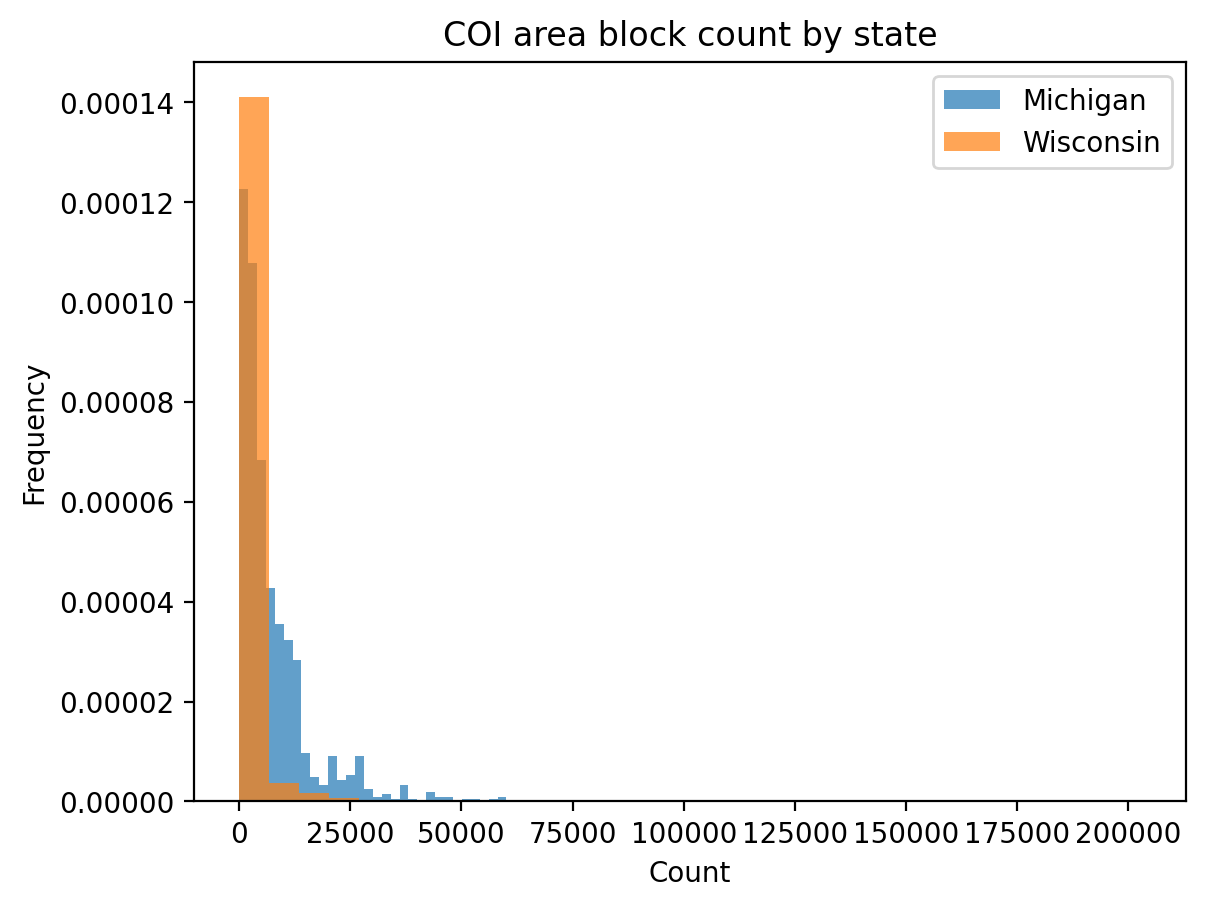

In [42]:
fig, ax = plt.subplots()
for state, df in state_cois.items():
    df["block_count"].plot.hist(label=state, alpha=0.7, bins=30, ax=ax, density=True)
plt.title("COI area block count by state")
plt.xlabel("Count")
plt.legend()
plt.show()

User-generated data is susceptible to extreme outliers. Let's remove the extreme tails and zoom in a bit...

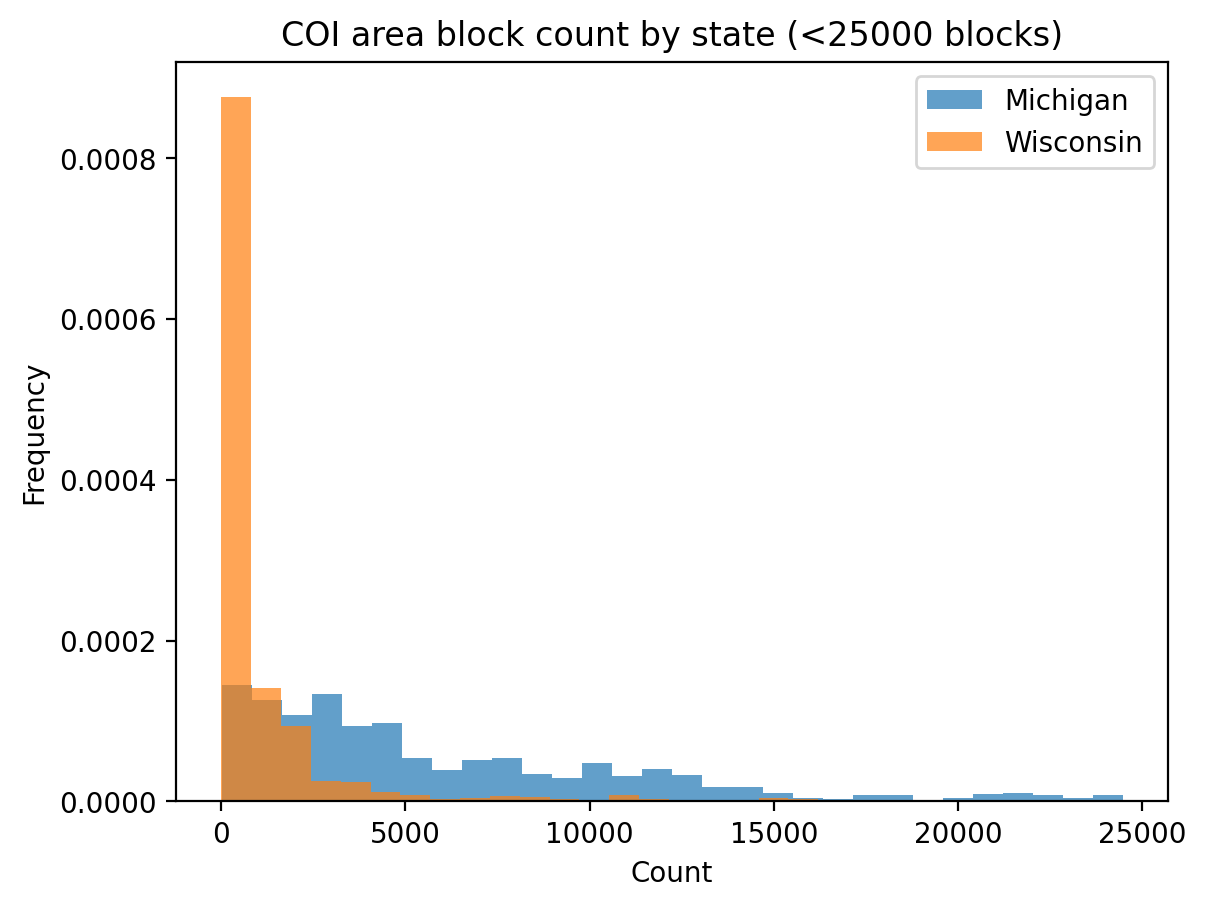

In [43]:
fig, ax = plt.subplots()
hist_params = dict(alpha=0.7, bins=30, ax=ax, density=True)
max_blocks = 25000
for state, df in state_cois.items():
    df["block_count"][df["block_count"] < max_blocks].plot.hist(label=state, alpha=0.7, bins=30, ax=ax, density=True)
plt.title(f"COI area block count by state (<{max_blocks} blocks)")
plt.xlabel("Count")
plt.legend()
plt.show()

OK that was a count of blocks in the COIs -- let's switch it up and do a comparison of land area.  

In [44]:
state_fips = {"Michigan": "26", "Wisconsin": "55"}

In [45]:
block_gdfs = {
    state: gpd.read_file(f"https://www2.census.gov/geo/tiger/TIGER2024/TABBLOCK20/tl_2024_{fips}_tabblock20.zip").set_index("GEOID20")
    for state, fips in state_fips.items()
}

In [46]:
land_areas = {
    state: dict(gdf["ALAND20"])
    for state, gdf in block_gdfs.items()
}

In [47]:
def compute_land_area(blocks):
    return sum(land_areas[state][geoid] for geoid in blocks)

for state, df in state_cois.items():
    df["land_area"] = df["blocks_2020"].apply(compute_land_area)

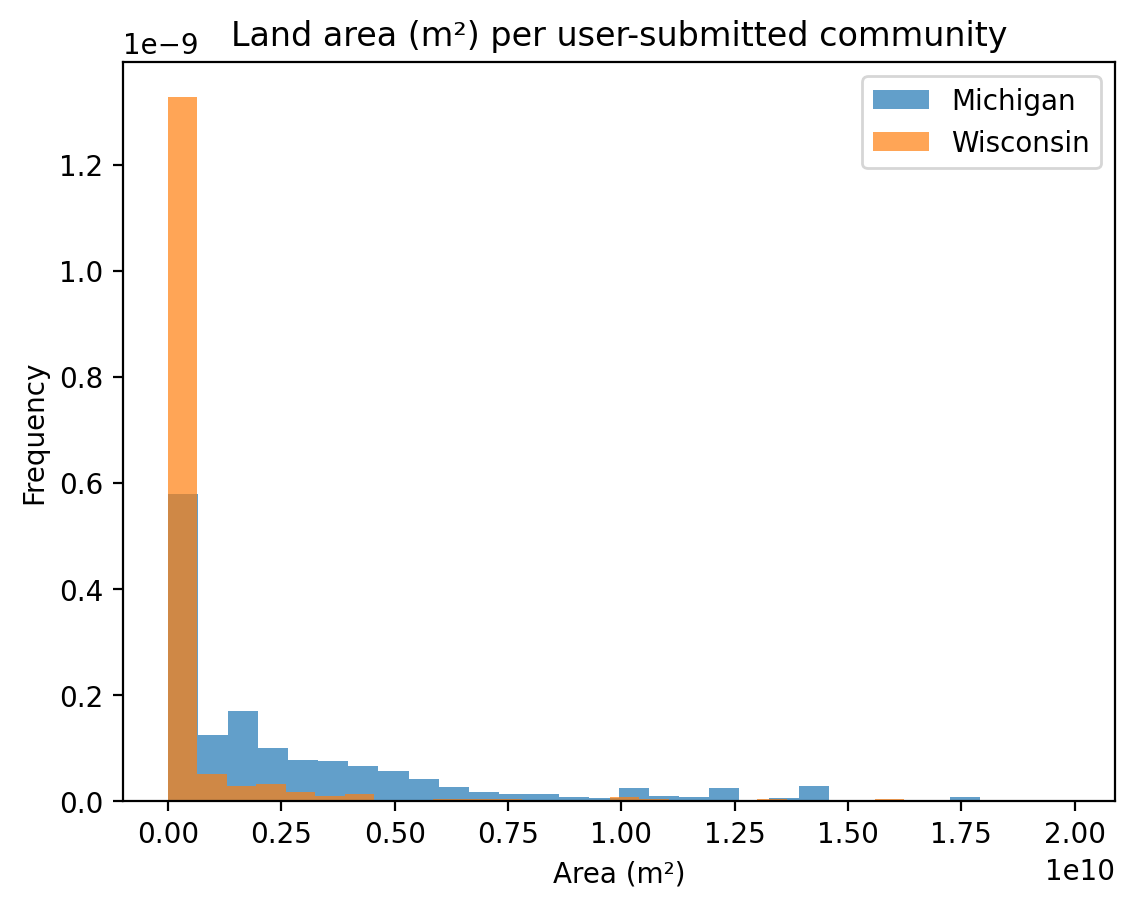

In [48]:
fig, ax = plt.subplots()
max_land_area = 2 * 10**10
for state, df in state_cois.items():
    df["land_area"][df["land_area"] < max_land_area].plot.hist(label=state, alpha=0.7, bins=30, ax=ax, density=True)
plt.title("Land area (m²) per user-submitted community")
plt.xlabel("Area (m²)")
plt.legend()
plt.show()

One last little thing to try -- let's try to figure out if the small communities in Michigan are in fact *urban* neighborhoods.  One way to get that question is to single out Detroit, which makes up about 20% of the land area in Wayne County, but 80% of the population.

We'll filter down to user-submitted communities that are in Wayne (applying a threshold such as 80%) and see what share of the full dataset that captures.  Then, we'll plot the sizes of the communities in Wayne and out of Wayne to see if the big spike in very small communities happens in Detroit.

In [49]:
def mostly_in_wayne(geoids):
    # Wayne County, MI is "26163".
    in_county = 0
    for geoid in geoids:
        if geoid[:5] == "26163":
            in_county += 1
    return (in_county / len(geoids)) >= 0.8

def mostly_in_milwaukee(geoids):
    # Milwaukee County, WI is "55079".
    in_county = 0
    for geoid in geoids:
        if geoid[:5] == "55079":
            in_county += 1
    return (in_county / len(geoids)) >= 0.8

state_cois["Michigan"]["mostly_in_wayne"] = state_cois["Michigan"]["blocks_2020"].apply(mostly_in_wayne)
state_cois["Wisconsin"]["mostly_in_milwaukee"] = state_cois["Wisconsin"]["blocks_2020"].apply(mostly_in_milwaukee)

In [50]:
print("there are",len(state_cois["Michigan"]),"COIs in the whole state")
print("and",state_cois["Michigan"]["mostly_in_wayne"].sum(),"COIs mostly in Wayne")

there are 1037 COIs in the whole state
and 101 COIs mostly in Wayne


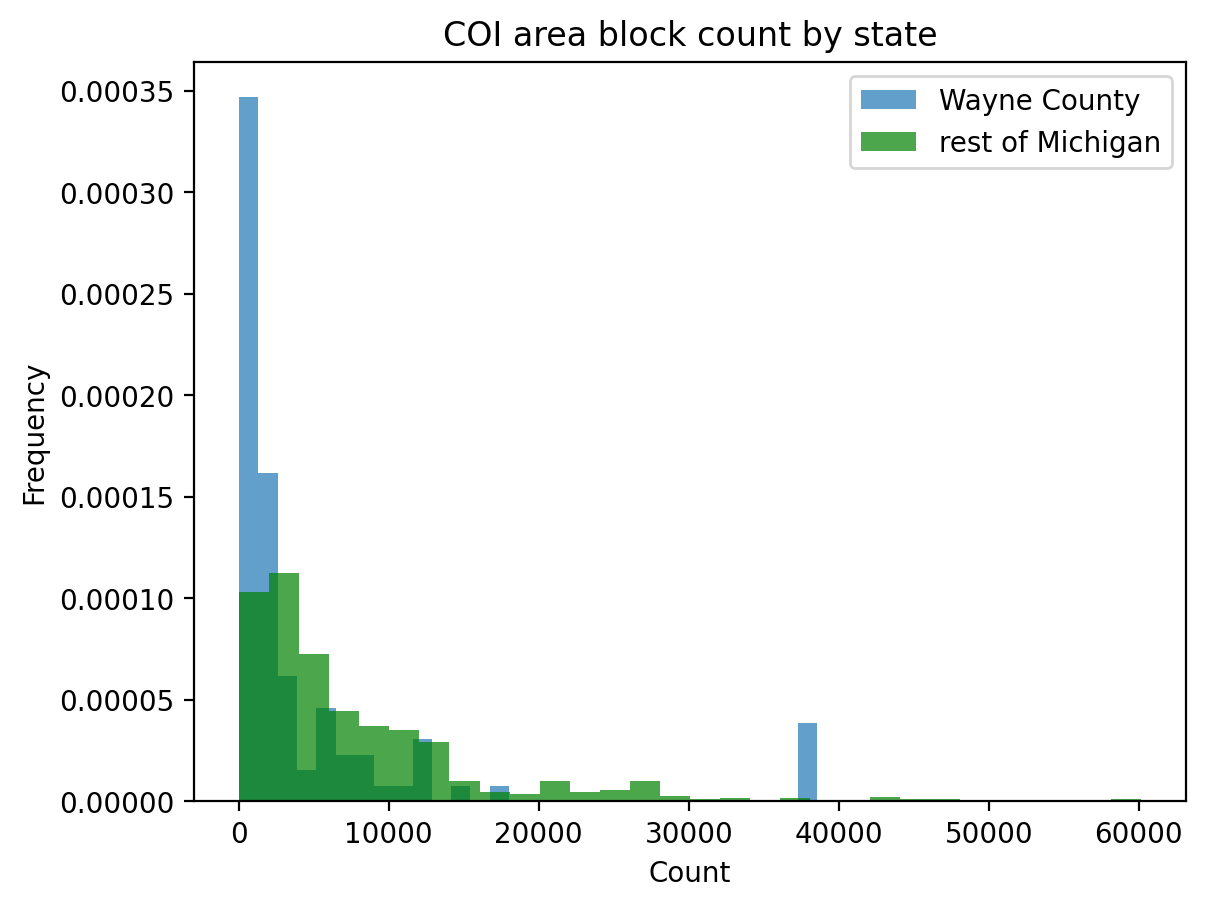

In [51]:
fig, ax = plt.subplots()
state_cois["Michigan"][state_cois["Michigan"]["mostly_in_wayne"]]["block_count"].plot.hist(label="Wayne County", alpha=0.7, bins=30, ax=ax, density=True)
state_cois["Michigan"][~state_cois["Michigan"]["mostly_in_wayne"]]["block_count"].plot.hist(label="rest of Michigan", alpha=0.7, bins=30, ax=ax, color="green", density=True)
plt.title("COI area block count by state")
plt.xlabel("Count")
plt.legend()
plt.show()

What do you think?  

#Homework 9 -- None!
